# EDA of Vitamin Deficiency Dataset

In [2]:
# Exploring the dataset structure
print("Dataset Overview:")
print("=" * 50)
print(f"Total samples: {len(df)}\n")
print(df.info())

# Check for missing values
print(f"\nMissing values: \n{df.isnull().sum()}")

# Check for duplicates
print("-" * 50)
print(f"Duplicate entries: {df.duplicated().sum()}")

# Basic info of the dataset
print("\nBasic Statistics:")
print("=" * 50)
print(df.info())

# Different diseases in the dataset
print("\nDisease Counts:")
print("=" * 50)
print(df['disease_diagnosis'].value_counts())

Dataset Overview:
Total samples: 4000

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        4000 non-null   int64  
 1   gender                     4000 non-null   str    
 2   bmi                        4000 non-null   float64
 3   smoking_status             4000 non-null   str    
 4   alcohol_consumption        2722 non-null   str    
 5   exercise_level             4000 non-null   str    
 6   diet_type                  4000 non-null   str    
 7   sun_exposure               4000 non-null   str    
 8   income_level               4000 non-null   str    
 9   latitude_region            4000 non-null   str    
 10  vitamin_a_percent_rda      4000 non-null   float64
 11  vitamin_c_percent_rda      4000 non-null   float64
 12  vitamin_d_percent_rda      4000 non-null   float64
 13  vitamin_e_percent_rd

# Summary after EDA

Upon analysis it appears that both the "alcohol_consumption" and "symptoms_list" features have null values. However, it appears that both features have entries that are non-null but are mistakingly being picked up as null ("None").

In [3]:
# Correcting mistaken missing value in 'alcohol_consumption' column
df['alcohol_consumption'] = df['alcohol_consumption'].fillna("No Consumption")

# Verify that there are no more missing values in 'alcohol_consumption'
print("Missing values in 'alcohol_consumption' after imputation:")
print(df['alcohol_consumption'].isnull().sum())

Missing values in 'alcohol_consumption' after imputation:
0


In [4]:
# Removing symptom_list column due to high missing values and potential data quality issues
df = df.drop(columns=['symptoms_list'])

In [5]:
# Checking for missing values again after corrections
print(f"\nMissing values: \n{df.isnull().sum()}")


Missing values: 
age                          0
gender                       0
bmi                          0
smoking_status               0
alcohol_consumption          0
exercise_level               0
diet_type                    0
sun_exposure                 0
income_level                 0
latitude_region              0
vitamin_a_percent_rda        0
vitamin_c_percent_rda        0
vitamin_d_percent_rda        0
vitamin_e_percent_rda        0
vitamin_b12_percent_rda      0
folate_percent_rda           0
calcium_percent_rda          0
iron_percent_rda             0
hemoglobin_g_dl              0
serum_vitamin_d_ng_ml        0
serum_vitamin_b12_pg_ml      0
serum_folate_ng_ml           0
symptoms_count               0
has_night_blindness          0
has_fatigue                  0
has_bleeding_gums            0
has_bone_pain                0
has_muscle_weakness          0
has_numbness_tingling        0
has_memory_problems          0
has_pale_skin                0
disease_diagnosis    

## Visualizing the data

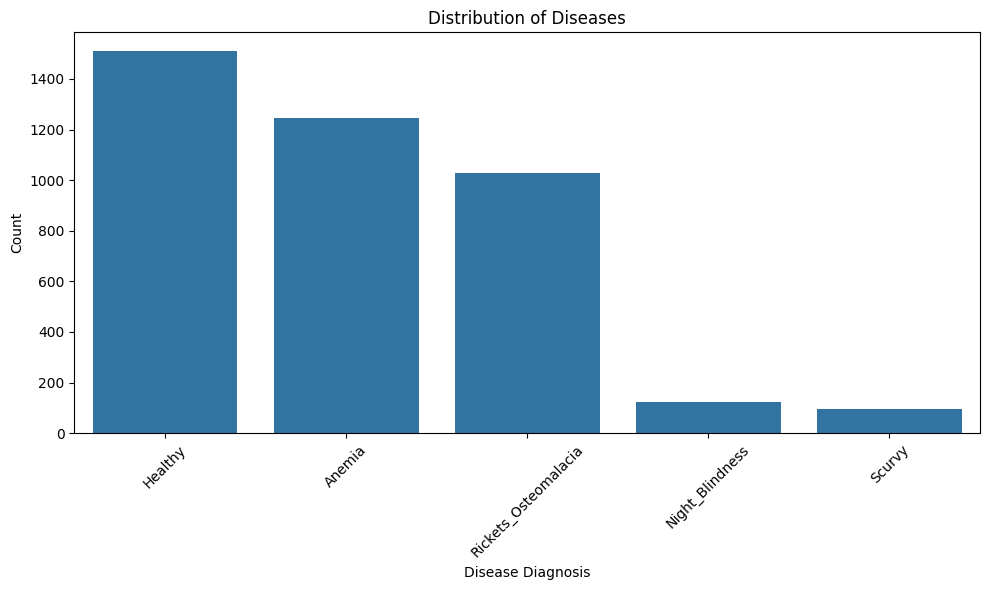

In [6]:
# Visualize the distribution of diseases
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='disease_diagnosis', order=df['disease_diagnosis'].value_counts().index)
plt.title('Distribution of Diseases')
plt.xlabel('Disease Diagnosis')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

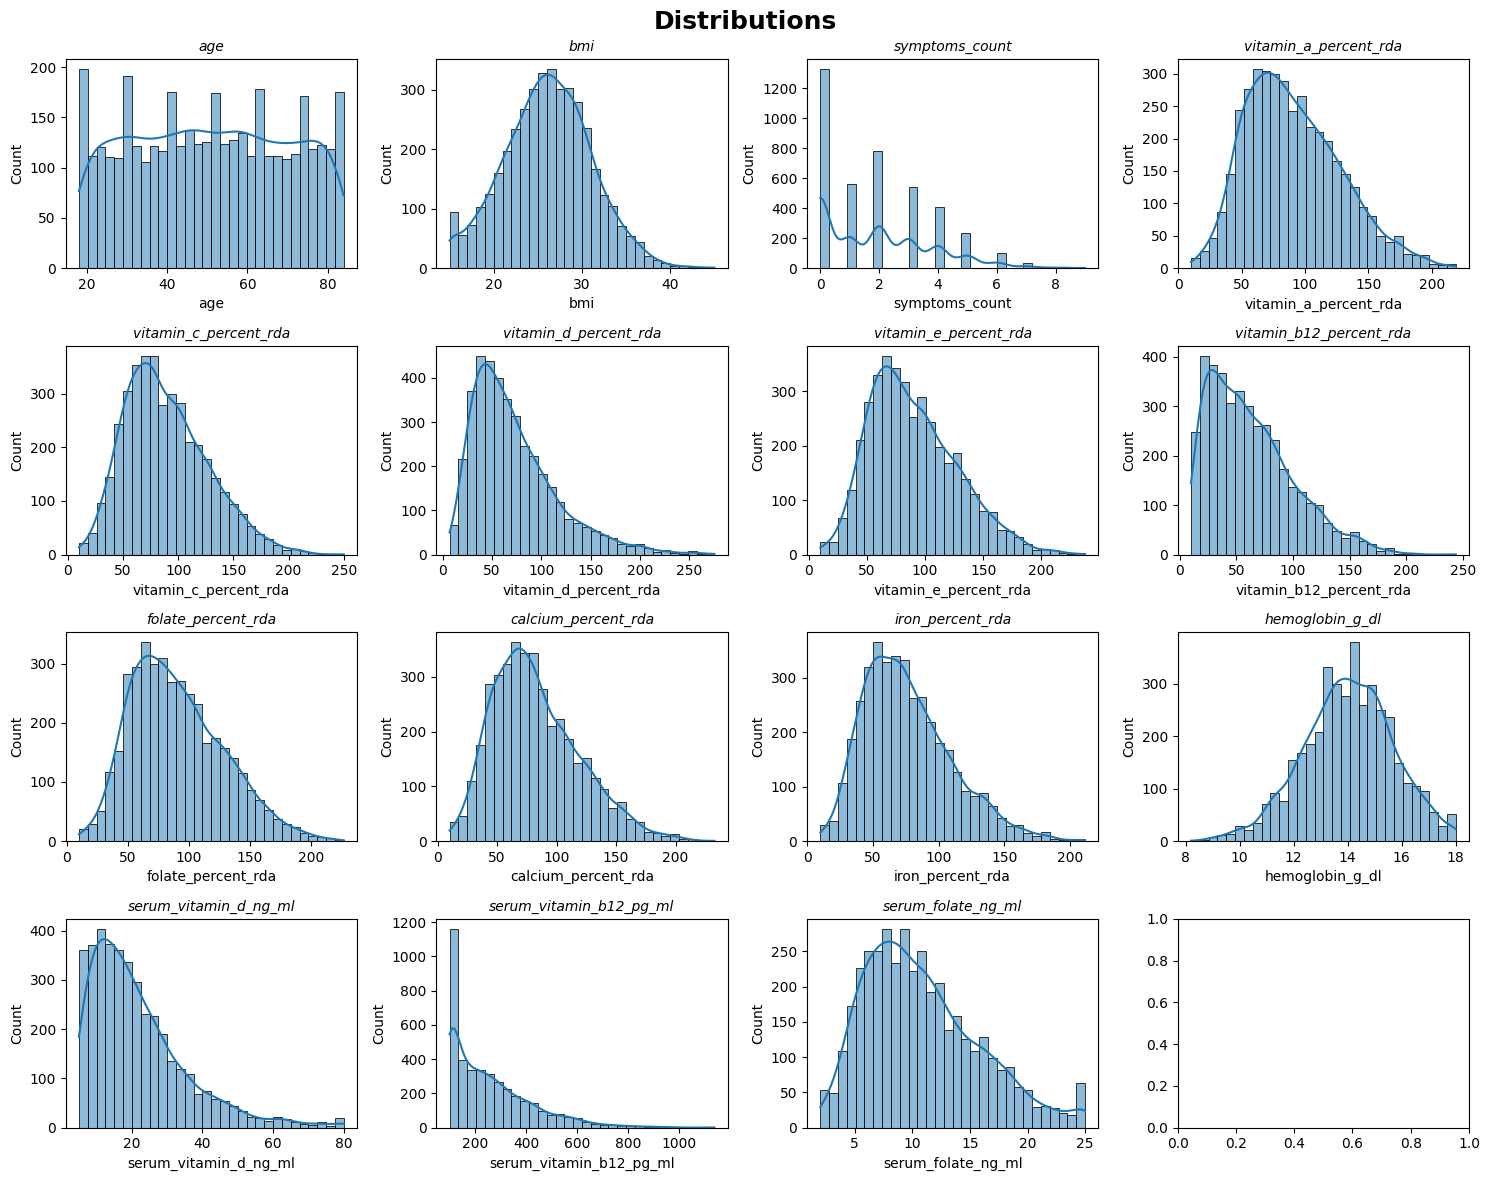

In [7]:
# Further visualizations to gleam more insights from the data
columns = [
    'age', 'bmi', 'symptoms_count',
    'vitamin_a_percent_rda', 'vitamin_c_percent_rda', 'vitamin_d_percent_rda', 'vitamin_e_percent_rda',
    'vitamin_b12_percent_rda', 'folate_percent_rda', 'calcium_percent_rda', 'iron_percent_rda',
    'hemoglobin_g_dl', 'serum_vitamin_d_ng_ml', 'serum_vitamin_b12_pg_ml', 'serum_folate_ng_ml'
]

fig , axes = plt.subplots(nrows = 4, ncols=4 , figsize=(15,12))
fig.suptitle('Distributions', fontsize = 18, fontweight = 'bold')

for i,col in enumerate (columns):
      row = i//4
      col_idx = i%4
      ax = axes[row,col_idx]
      sns.histplot(data = df, x = col, kde = True,ax = ax, bins = 30)
      ax.set_title(col, fontsize = 10, fontstyle = 'italic')
     
    
plt.tight_layout()
plt.show() 

# Heat map

<Axes: >

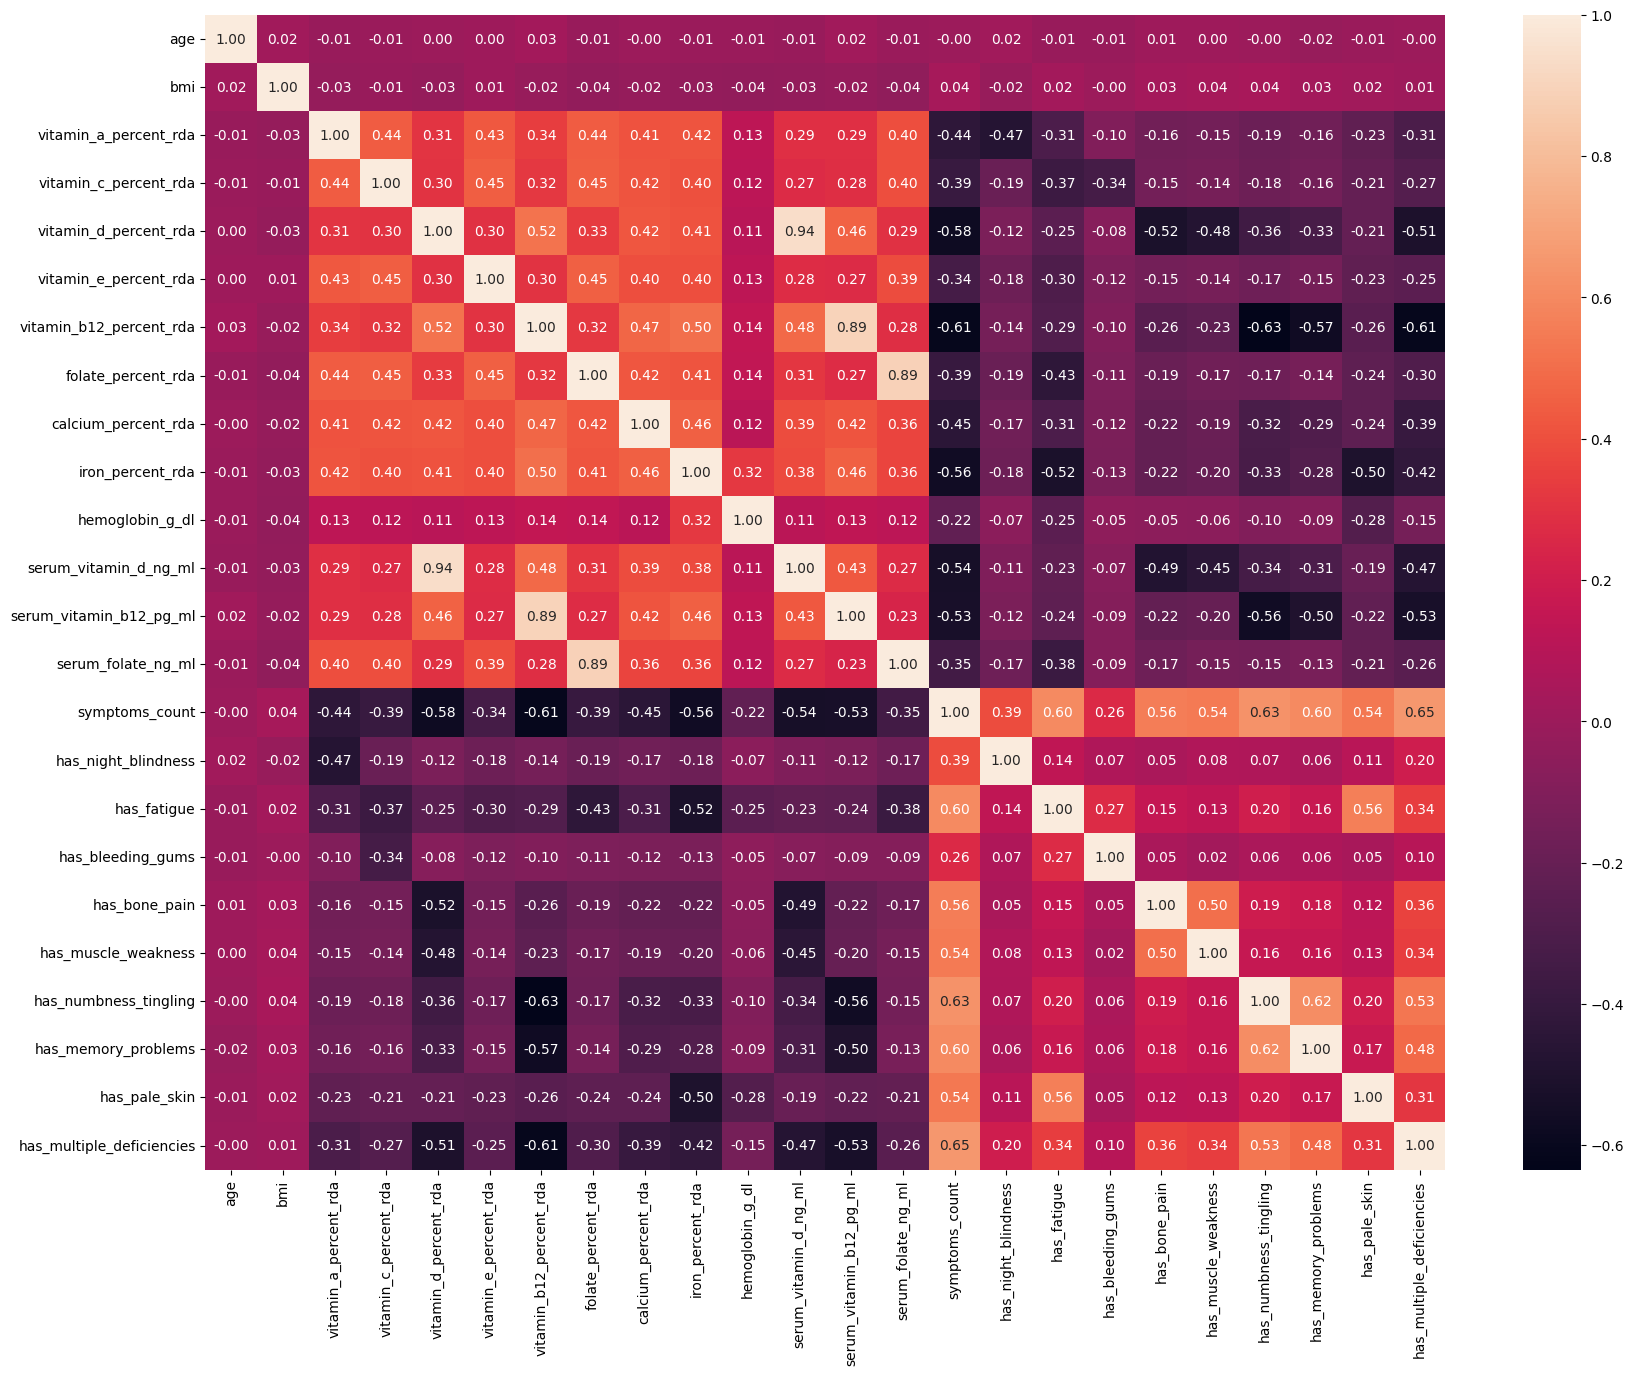

In [8]:
# Correlation heatmap of numeric features
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt=".2f")

# correlation between diet and certain diseases

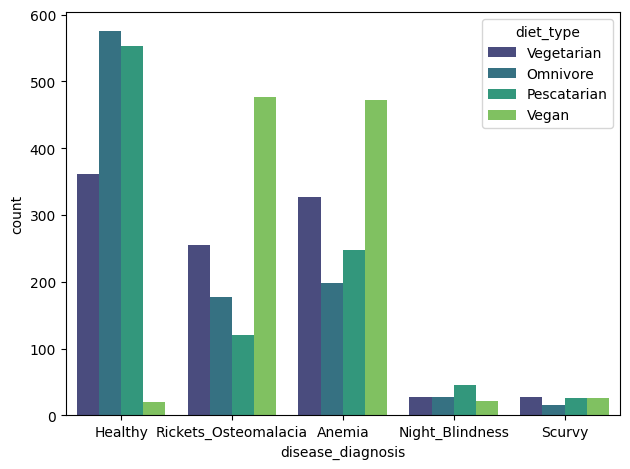

In [10]:
sns.countplot(data=df, x='disease_diagnosis', hue='diet_type', palette='viridis')
plt.tight_layout()
plt.show()

# Creating the Classification Model (RFC)

In [12]:
# Model: Random Forest Classifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# Select numeric features for a first baseline model
X = df.select_dtypes(include=[np.number]).copy()
# Drop obvious identifier columns if present
for col in ['patient_id', 'id']:
    if col in X.columns:
        X = X.drop(columns=[col])
y = df['disease_diagnosis'].astype(str).copy()

# Remove rows with missing features or target
mask = X.notnull().all(axis=1) & y.notnull()
X = X[mask]
y = y[mask]

print(f'Using {X.shape[0]} samples and {X.shape[1]} numeric features.')

# Encode target labels
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# Train Random Forest
clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

# Predictions & evaluation
y_pred = clf.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

# Save the trained model and label encoder
joblib.dump(clf, 'rfc_model.joblib')
joblib.dump(le, 'label_encoder.joblib')

Using 4000 samples and 24 numeric features.
Accuracy: 0.945

Classification Report:
                      precision    recall  f1-score   support

              Anemia       0.94      0.95      0.95       249
             Healthy       0.99      0.96      0.97       302
     Night_Blindness       0.96      0.92      0.94        24
Rickets_Osteomalacia       0.88      0.92      0.90       206
              Scurvy       0.95      1.00      0.97        19

            accuracy                           0.94       800
           macro avg       0.94      0.95      0.95       800
        weighted avg       0.95      0.94      0.95       800

Confusion Matrix:
[[236   0   0  13   0]
 [  2 290   0  10   0]
 [  0   0  22   2   0]
 [ 12   3   1 189   1]
 [  0   0   0   0  19]]


['label_encoder.joblib']

# Creating the XGBoost Model

In [18]:
# XGBoost model to predict disease diagnosis
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# Try to reuse precomputed X, y and train/test split if available
try:
    X_train, X_test, y_train, y_test
except NameError:
    # Recreate features/target and split if variables aren't present
    X = df.select_dtypes(include=[np.number]).copy()
    for col in ['patient_id', 'id']:
        if col in X.columns:
            X = X.drop(columns=[col])
    y = df['disease_diagnosis'].astype(str).copy()
    mask = X.notnull().all(axis=1) & y.notnull()
    X = X[mask]
    y = y[mask]
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

# Fit XGBoost classifier (uses GPU if configured, otherwise CPU)
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_estimators=200)
# Use early_stopping_rounds for compatibility across xgboost versions
xgb_clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], early_stopping_rounds=20, verbose=False)

# Predict and evaluate
y_pred_xgb = xgb_clf.predict(X_test)
print('XGBoost Accuracy:', accuracy_score(y_test, y_pred_xgb))
print('\nXGBoost Classification Report:')
# If label encoder exists, show class names, otherwise show numeric labels
if 'le' in globals():
    target_names = le.classes_
else:
    target_names = None
print(classification_report(y_test, y_pred_xgb, target_names=target_names))
print('XGBoost Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_xgb))

# Save model
joblib.dump(xgb_clf, 'xgb_model.joblib')

TypeError: XGBClassifier.fit() got an unexpected keyword argument 'early_stopping_rounds'